# 05 Hyperparameter Optimization

This notebook tunes XGBoost hyperparameters.

We compare three search strategies:

- Grid Search
- Random Search
- Bayesian Search

All candidates are evaluated with the same evaluation logic used in the baseline training notebook.

## XGBoost Parameters We Tune

XGBoost is a gradient boosting model. It builds many small decision trees sequentially. Each new tree tries to improve the current model.

A simplified boosting update is:

```text
F_m(x) = F_{m-1}(x) + eta * f_m(x)
```

Where:

- `F_m(x)` is the model after step `m`.
- `f_m(x)` is the new tree.
- `eta` is the learning rate.

The parameters below control three main aspects: how many trees are built, how complex each tree may become, and how strongly the model is regularized.

| Parameter | Intuition |
| --- | --- |
| `n_estimators` | Number of boosting rounds / trees. More trees give the model more chances to correct errors, but can also increase overfitting and training time. |
| `learning_rate` | Step size of each tree. A smaller value makes each update more cautious and often needs more trees. A larger value learns faster but can overshoot useful patterns. |
| `max_depth` | Maximum depth of each tree. Shallow trees capture simpler patterns. Deeper trees can capture interactions but may memorize noise. |
| `min_child_weight` | Minimum amount of training signal required in a child node. Larger values make the model more conservative: it avoids splits that are supported by only very small or weak groups of observations. |
| `subsample` | Fraction of rows used for each tree. Values below `1.0` add randomness and can reduce overfitting. |
| `colsample_bytree` | Fraction of columns used for each tree. This can reduce reliance on a small set of features and can make trees less correlated. |
| `gamma` | Minimum loss reduction required to make a split. Higher values mean that a split must provide more improvement before it is accepted. |
| `reg_lambda` | L2 regularization. Larger values shrink model weights and can make the model smoother. |
| `reg_alpha` | L1 regularization. Can push some weights toward zero and encourage simpler models. |
| `scale_pos_weight` | Weight for the positive class. Useful when the target class is imbalanced. |

We tune only a focused subset in this notebook. A larger search space is possible, but it would make the local demo slower and harder to interpret.

## Search Strategies

### Grid Search

Grid Search evaluates every combination in a predefined grid.

If we define parameter sets `G_1, G_2, ..., G_k`, the total number of runs is:

```text
|G_1| * |G_2| * ... * |G_k|
```

It is systematic, but it can become expensive quickly.

### Random Search

Random Search samples a fixed number of combinations from parameter distributions.

It does not test every possible combination. This is often efficient when only a few parameters strongly influence performance.

### Bayesian Search

Bayesian Search uses previous trials to choose promising next configurations.

The optimizer builds a surrogate view of the objective function and balances:

- exploration: try uncertain regions
- exploitation: try regions that already look promising

In this notebook, Optuna is used for Bayesian optimization.

## 1. Setup

In [1]:
from datetime import datetime
import json
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import optuna
import pandas as pd
from scipy.stats import loguniform, randint, uniform
from sklearn.metrics import (
    accuracy_score,
    brier_score_loss,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold, cross_val_score
from xgboost import XGBClassifier

optuna.logging.set_verbosity(optuna.logging.WARNING)

pd.set_option("display.max_columns", 120)
pd.set_option("display.max_rows", 120)

RANDOM_STATE = 42
CV_SPLITS = 3
SCORING = "f1"


def find_project_root(start: Path) -> Path:
    for path in [start, *start.parents]:
        if (path / "data" / "processed" / "X_train_processed.csv").exists():
            return path
    raise FileNotFoundError("Could not find project root with processed training data.")


PROJECT_ROOT = find_project_root(Path.cwd())
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODEL_RESULTS_DIR = PROJECT_ROOT / "reports" / "model_results"

print(f"Project root: {PROJECT_ROOT}")
print(f"Model results directory: {MODEL_RESULTS_DIR}")

/home/cbaldermann/Envs/ads_II/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Project root: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master
Model results directory: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/reports/model_results


## 2. Load Processed Data

In [2]:
X_train = pd.read_csv(PROCESSED_DIR / "X_train_processed.csv")
X_test = pd.read_csv(PROCESSED_DIR / "X_test_processed.csv")
y_train = pd.read_csv(PROCESSED_DIR / "y_train.csv")["ChurnBinary"]
y_test = pd.read_csv(PROCESSED_DIR / "y_test.csv")["ChurnBinary"]
test_metadata = pd.read_csv(PROCESSED_DIR / "test_metadata.csv")

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")
print(f"Test metadata: {test_metadata.shape}")

X_train: (5634, 53)
X_test:  (1409, 53)
y_train: (5634,)
y_test:  (1409,)
Test metadata: (1409, 11)


## 3. Evaluation Function

In [3]:
BUSINESS_PARAMS = {
    "retention_offer_cost": 50,
    "customer_value_if_retained": 300,
    "retention_success_rate": 0.30,
}


def calculate_business_kpis(y_true: pd.Series, y_score, business_params: dict) -> dict:
    offer_cost = business_params["retention_offer_cost"]
    customer_value = business_params["customer_value_if_retained"]
    success_rate = business_params["retention_success_rate"]

    business_df = pd.DataFrame({
        "y_true": y_true.reset_index(drop=True),
        "churn_probability": y_score,
    })
    business_df["expected_retention_value"] = (
        business_df["churn_probability"] * customer_value * success_rate
    )
    business_df["expected_net_value"] = business_df["expected_retention_value"] - offer_cost
    business_df["contact_customer"] = business_df["expected_net_value"] > 0

    contacted = business_df[business_df["contact_customer"]]
    true_churn_contacted = int((contacted["y_true"] == 1).sum())
    non_churn_contacted = int((contacted["y_true"] == 0).sum())
    missed_churn = int(((business_df["y_true"] == 1) & (~business_df["contact_customer"])).sum())

    expected_gross_value = contacted["expected_retention_value"].sum()
    campaign_cost = len(contacted) * offer_cost
    expected_net_value = expected_gross_value - campaign_cost
    realized_net_value = true_churn_contacted * customer_value * success_rate - campaign_cost

    return {
        "contacted_customers": int(len(contacted)),
        "true_churn_customers_contacted": true_churn_contacted,
        "non_churn_customers_contacted": non_churn_contacted,
        "missed_churn_customers": missed_churn,
        "expected_net_value": float(expected_net_value),
        "realized_net_value_for_backtest": float(realized_net_value),
    }


def evaluate_model(model, model_name: str, business_params: dict | None = None) -> dict:
    y_train_pred = model.predict(X_train)
    y_test_pred = model.predict(X_test)
    y_test_score = model.predict_proba(X_test)[:, 1]

    result = {
        "model_name": model_name,
        "accuracy": accuracy_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred, zero_division=0),
        "recall": recall_score(y_test, y_test_pred, zero_division=0),
        "f1": f1_score(y_test, y_test_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, y_test_score),
        "brier_score": brier_score_loss(y_test, y_test_score),
        "train_f1": f1_score(y_train, y_train_pred, zero_division=0),
        "test_f1": f1_score(y_test, y_test_pred, zero_division=0),
        "generalization_gap": (
            f1_score(y_train, y_train_pred, zero_division=0)
            - f1_score(y_test, y_test_pred, zero_division=0)
        ),
        "confusion_matrix": confusion_matrix(y_test, y_test_pred, labels=[0, 1]),
        "classification_report": classification_report(
            y_test,
            y_test_pred,
            zero_division=0,
        ),
        "y_pred": y_test_pred,
        "y_score": y_test_score,
    }

    if business_params is not None:
        result.update(calculate_business_kpis(y_test, y_test_score, business_params))

    return result

## 4. Default XGBoost Baseline

In [4]:
base_xgb_params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "random_state": RANDOM_STATE,
    "n_jobs": -1,
}

default_xgb = XGBClassifier(**base_xgb_params)
default_xgb.fit(X_train, y_train)

default_result = evaluate_model(default_xgb, "XGBoost default", BUSINESS_PARAMS)
pd.DataFrame([{k: v for k, v in default_result.items() if not isinstance(v, (dict, list)) and k not in ["confusion_matrix", "classification_report"]}]).round(4)

,model_name,accuracy,precision,recall,f1,roc_auc,brier_score,train_f1,test_f1,generalization_gap,y_pred,y_score,contacted_customers,true_churn_customers_contacted,non_churn_customers_contacted,missed_churn_customers,expected_net_value,realized_net_value_for_backtest
0,XGBoost default,0.785,0.6134,0.5134,0.559,0.8247,0.1496,0.9215,0.559,0.3625,"[0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, ...","[0.007309501, 0.94382316, 0.10133452, 0.234752...",279,174,105,200,5098.293,1710.0


## Excursus: Cross-Validation Logic

Before tuning hyperparameters, we need a reliable way to compare parameter settings.

If we evaluated every setting only on one fixed validation split, the result could depend too much on that particular split. Cross-validation reduces this dependency by repeating the train-validation process several times:

1. Split the training data into `k` folds.
2. Train the model on `k - 1` folds.
3. Validate it on the remaining fold.
4. Repeat until every fold has been used once as validation data.
5. Average the validation scores.

In this notebook, the search methods use `StratifiedKFold`. Stratification keeps the churn class distribution similar across folds. This matters because churn is not evenly balanced in the dataset.

The test set is not part of cross-validation. It stays untouched until the final evaluation of the selected model.


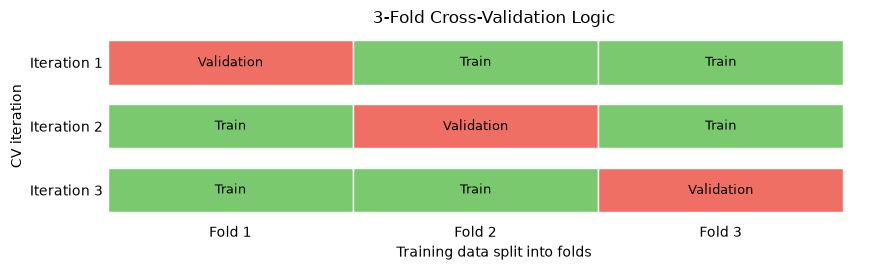

In [5]:
def plot_cross_validation_logic(n_folds: int = CV_SPLITS) -> None:
    fig, ax = plt.subplots(figsize=(9, 2.8))

    train_color = "#7bc96f"
    validation_color = "#f06f64"
    edge_color = "#ffffff"

    for fold_idx in range(n_folds):
        for block_idx in range(n_folds):
            color = validation_color if block_idx == fold_idx else train_color
            label = "Validation" if block_idx == fold_idx else "Train"
            ax.barh(
                y=fold_idx,
                width=1,
                left=block_idx,
                height=0.7,
                color=color,
                edgecolor=edge_color,
            )
            ax.text(
                block_idx + 0.5,
                fold_idx,
                label,
                ha="center",
                va="center",
                fontsize=9,
                color="black",
            )

    ax.set_title(f"{n_folds}-Fold Cross-Validation Logic")
    ax.set_xlabel("Training data split into folds")
    ax.set_ylabel("CV iteration")
    ax.set_xticks([i + 0.5 for i in range(n_folds)])
    ax.set_xticklabels([f"Fold {i + 1}" for i in range(n_folds)])
    ax.set_yticks(range(n_folds))
    ax.set_yticklabels([f"Iteration {i + 1}" for i in range(n_folds)])
    ax.invert_yaxis()
    ax.spines[["top", "right", "left", "bottom"]].set_visible(False)
    ax.tick_params(axis="both", length=0)

    plt.tight_layout()
    plt.show()


plot_cross_validation_logic()


## 5. Grid Search

### Grid Search Space

The grid is intentionally small. It is designed for a local teaching example, not for exhaustive production tuning.

| Parameter | Values | Why these values are plausible here |
| --- | --- | --- |
| `n_estimators` | `[100, 200]` | Tests a moderate and a larger number of trees while keeping runtime manageable. |
| `learning_rate` | `[0.03, 0.1]` | `0.1` is a common starting point. `0.03` tests a more cautious update size. |
| `max_depth` | `[2, 3]` | Keeps individual trees shallow because overfitting was already visible in the baseline notebook. |
| `subsample` | `[0.8, 1.0]` | Compares using all rows with using a random 80% of rows per tree as a simple anti-overfitting measure. |

This grid contains:

```text
2 * 2 * 2 * 2 = 16 combinations
```

With 3-fold cross-validation, this means 48 model fits.

In [6]:
grid_param_space = {
    "n_estimators": [100, 200],
    "learning_rate": [0.03, 0.1],
    "max_depth": [2, 3],
    "subsample": [0.8, 1.0],
}

grid_search = GridSearchCV(
    estimator=XGBClassifier(**base_xgb_params),
    param_grid=grid_param_space,
    scoring=SCORING,
    cv=StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    n_jobs=-1,
    verbose=0,
)

grid_search.fit(X_train, y_train)

print(f"Best CV F1: {grid_search.best_score_:.4f}")
grid_search.best_params_

Best CV F1: 0.5875


{'learning_rate': 0.1, 'max_depth': 2, 'n_estimators': 100, 'subsample': 0.8}

In [7]:
grid_result = evaluate_model(grid_search.best_estimator_, "XGBoost Grid Search", BUSINESS_PARAMS)
pd.DataFrame([{k: v for k, v in grid_result.items() if not isinstance(v, (dict, list)) and k not in ["confusion_matrix", "classification_report"]}]).round(4)

,model_name,accuracy,precision,recall,f1,roc_auc,brier_score,train_f1,test_f1,generalization_gap,y_pred,y_score,contacted_customers,true_churn_customers_contacted,non_churn_customers_contacted,missed_churn_customers,expected_net_value,realized_net_value_for_backtest
0,XGBoost Grid Search,0.8062,0.676,0.5187,0.587,0.8438,0.136,0.6107,0.587,0.0237,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0.06955935, 0.7664781, 0.08775715, 0.3448701,...",235,164,71,210,2968.1348,3010.0


## 6. Random Search

In [8]:
random_param_space = {
    "n_estimators": randint(80, 350),
    "learning_rate": loguniform(0.01, 0.2),
    "max_depth": randint(2, 6),
    "min_child_weight": randint(1, 8),
    "subsample": uniform(0.65, 0.35),
    "colsample_bytree": uniform(0.65, 0.35),
    "gamma": uniform(0.0, 2.0),
    "reg_lambda": loguniform(0.1, 10.0),
}

random_search = RandomizedSearchCV(
    estimator=XGBClassifier(**base_xgb_params),
    param_distributions=random_param_space,
    n_iter=20,
    scoring=SCORING,
    cv=StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE),
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbose=0,
)

random_search.fit(X_train, y_train)

print(f"Best CV F1: {random_search.best_score_:.4f}")
random_search.best_params_

Best CV F1: 0.5961


{'colsample_bytree': np.float64(0.7810890415965769),
 'gamma': np.float64(1.9014286128198323),
 'learning_rate': np.float64(0.08960785365368121),
 'max_depth': 2,
 'min_child_weight': 5,
 'n_estimators': 182,
 'reg_lambda': np.float64(0.7792297153882993),
 'subsample': np.float64(0.684991220536301)}

In [9]:
random_result = evaluate_model(random_search.best_estimator_, "XGBoost Random Search", BUSINESS_PARAMS)
pd.DataFrame([{k: v for k, v in random_result.items() if not isinstance(v, (dict, list)) and k not in ["confusion_matrix", "classification_report"]}]).round(4)

,model_name,accuracy,precision,recall,f1,roc_auc,brier_score,train_f1,test_f1,generalization_gap,y_pred,y_score,contacted_customers,true_churn_customers_contacted,non_churn_customers_contacted,missed_churn_customers,expected_net_value,realized_net_value_for_backtest
0,XGBoost Random Search,0.8034,0.6714,0.508,0.5784,0.8456,0.135,0.6152,0.5784,0.0368,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0.026189703, 0.7864919, 0.08552644, 0.3354162...",234,166,68,208,3262.1523,3240.0


## 7. Bayesian Search with Optuna

In [10]:
def objective(trial: optuna.Trial) -> float:
    params = {
        **base_xgb_params,
        "n_estimators": trial.suggest_int("n_estimators", 80, 350),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.2, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 8),
        "subsample": trial.suggest_float("subsample", 0.65, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.65, 1.0),
        "gamma": trial.suggest_float("gamma", 0.0, 2.0),
        "reg_lambda": trial.suggest_float("reg_lambda", 0.1, 10.0, log=True),
    }

    model = XGBClassifier(**params)
    cv = StratifiedKFold(n_splits=CV_SPLITS, shuffle=True, random_state=RANDOM_STATE)
    scores = cross_val_score(model, X_train, y_train, scoring=SCORING, cv=cv, n_jobs=-1)
    return scores.mean()


study = optuna.create_study(direction="maximize", sampler=optuna.samplers.TPESampler(seed=RANDOM_STATE))
study.optimize(objective, n_trials=20)

print(f"Best CV F1: {study.best_value:.4f}")
study.best_params

Best CV F1: 0.5936


{'n_estimators': 156,
 'learning_rate': 0.05082341959721458,
 'max_depth': 2,
 'min_child_weight': 7,
 'subsample': 0.6760927252879199,
 'colsample_bytree': 0.9954104278101811,
 'gamma': 1.5444895385933148,
 'reg_lambda': 0.24970737145052724}

In [11]:
bayes_model = XGBClassifier(**base_xgb_params, **study.best_params)
bayes_model.fit(X_train, y_train)

bayes_result = evaluate_model(bayes_model, "XGBoost Bayesian Search", BUSINESS_PARAMS)
pd.DataFrame([{k: v for k, v in bayes_result.items() if not isinstance(v, (dict, list)) and k not in ["confusion_matrix", "classification_report"]}]).round(4)

,model_name,accuracy,precision,recall,f1,roc_auc,brier_score,train_f1,test_f1,generalization_gap,y_pred,y_score,contacted_customers,true_churn_customers_contacted,non_churn_customers_contacted,missed_churn_customers,expected_net_value,realized_net_value_for_backtest
0,XGBoost Bayesian Search,0.8077,0.6782,0.5241,0.5913,0.8467,0.135,0.6128,0.5913,0.0216,"[0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, ...","[0.035956927, 0.7255254, 0.07579134, 0.3759890...",228,160,68,214,2789.7773,3000.0


## 8. Compare Search Results

In [12]:
all_results = [default_result, grid_result, random_result, bayes_result]

comparison_columns = [
    "model_name",
    "accuracy",
    "precision",
    "recall",
    "f1",
    "roc_auc",
    "brier_score",
    "train_f1",
    "test_f1",
    "generalization_gap",
    "expected_net_value",
    "realized_net_value_for_backtest",
]

xgboost_comparison_df = pd.DataFrame([
    {column: result[column] for column in comparison_columns}
    for result in all_results
])

baseline_metrics = pd.read_csv(MODEL_RESULTS_DIR / "04_baseline_model_metrics.csv")
baseline_business = pd.read_csv(MODEL_RESULTS_DIR / "04_baseline_business_kpis.csv")

baseline_reference = (
    baseline_metrics
    .merge(baseline_business, on="model_name", how="left")
    .loc[lambda df: df["model_name"].eq("Logistic Regression"), comparison_columns]
    .assign(model_name="Logistic Regression (saved baseline)")
)

comparison_df = pd.concat(
    [baseline_reference, xgboost_comparison_df],
    ignore_index=True,
)

comparison_df["value_deviation"] = (
    comparison_df["realized_net_value_for_backtest"]
    - comparison_df["expected_net_value"]
)
comparison_df["value_deviation_percent"] = (
    comparison_df["value_deviation"]
    / comparison_df["expected_net_value"].abs()
    * 100
).round(2)

comparison_df.sort_values("f1", ascending=False).round(4)

,model_name,accuracy,precision,recall,f1,roc_auc,brier_score,train_f1,test_f1,generalization_gap,expected_net_value,realized_net_value_for_backtest,value_deviation,value_deviation_percent
4,XGBoost Bayesian Search,0.8077,0.6782,0.5241,0.5913,0.8467,0.1350,0.6128,0.5913,0.0216,2789.7773,3000.0,210.2227,7.54
2,XGBoost Grid Search,0.8062,0.6760,0.5187,0.5870,0.8438,0.1360,0.6107,0.5870,0.0237,2968.1348,3010.0,41.8652,1.41
3,XGBoost Random Search,0.8034,0.6714,0.5080,0.5784,0.8456,0.1350,0.6152,0.5784,0.0368,3262.1523,3240.0,-22.1523,-0.68
0,Logistic Regression (saved baseline),0.7977,0.6551,0.5027,0.5688,0.8448,0.1365,0.6036,0.5688,0.0348,3210.2335,2860.0,-350.2335,-10.91
1,XGBoost default,0.7850,0.6134,0.5134,0.5590,0.8247,0.1496,0.9215,0.5590,0.3625,5098.2930,1710.0,-3388.2930,-66.46


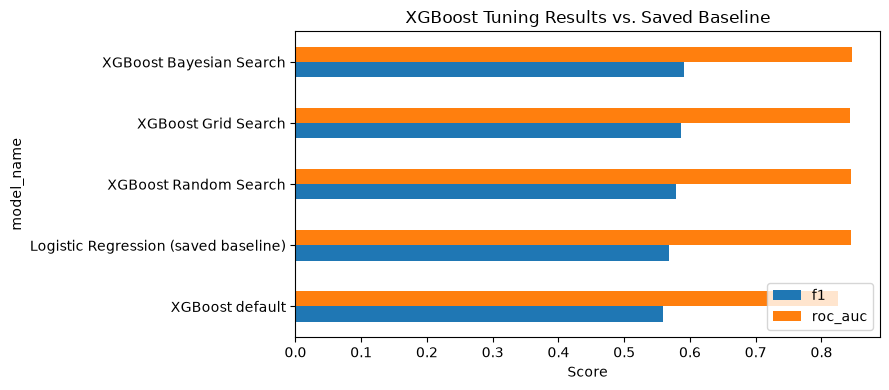

In [13]:
ax = comparison_df.sort_values("f1").plot(
    x="model_name",
    y=["f1", "roc_auc"],
    kind="barh",
    figsize=(9, 4),
)
ax.set_title("XGBoost Tuning Results vs. Saved Baseline")
ax.set_xlabel("Score")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Reflection: Is This a Fair Search Strategy Comparison?

This comparison is useful, but it is not a perfectly fair benchmark of search algorithms.

Several things differ at the same time:

- Grid Search uses a smaller, manually selected search space.
- Random Search and Bayesian Search explore more parameters.
- Grid Search evaluates 16 parameter combinations. With 3-fold cross-validation, this means 48 model fits.
- Random Search and Bayesian Search each evaluate 20 candidates. With 3-fold cross-validation, this means 60 model fits.

The comparison is therefore best read as a practical demonstration:

> Given small local search budgets, how do the strategies behave and what kind of results do they produce?

It should not be interpreted as proof that one search algorithm is generally better than another.

For a more controlled benchmark, we would need to define either:

- the same search space for all strategies, or
- the same compute budget, measured as total model fits or runtime.

In practice, both dimensions matter. Search space design and compute budget should be decided before running tuning experiments.

## Practice Note: Sequential XGBoost Tuning

In practice, XGBoost is often tuned iteratively rather than by searching all parameters at once.

The reason is that parameters influence each other:

- `learning_rate` and `n_estimators` form a pair. A smaller learning rate usually needs more trees.
- `max_depth`, `min_child_weight`, and `gamma` jointly control tree complexity.
- `subsample` and `colsample_bytree` add randomness and can reduce overfitting.
- `reg_alpha` and `reg_lambda` control regularization after the rough model shape is known.

A common practical workflow is:

1. Start with a stable default baseline.
2. Tune `n_estimators` and `learning_rate` to control the boosting process.
3. Tune tree complexity with `max_depth`, `min_child_weight`, and `gamma`.
4. Tune sampling with `subsample` and `colsample_bytree`.
5. Tune regularization with `reg_alpha` and `reg_lambda`.
6. Re-check the selected model on the same holdout test set and business KPI.

### Practical Search Range Heuristics

Good search ranges depend on the data size, signal strength, feature count, class balance, and runtime budget. The ranges below are starting points, not universal rules.

For this dataset:

- around 5,600 training rows
- binary classification
- imbalanced target
- about 50 processed features
- visible overfitting in the default XGBoost baseline

reasonable first ranges are:

| Parameter | Practical starting range | Reason |
| --- | --- | --- |
| `n_estimators` | `80` to `350` | Enough trees to learn useful patterns, but not so many that local search becomes slow. |
| `learning_rate` | `0.01` to `0.2` | Covers cautious learning and common faster-learning defaults. |
| `max_depth` | `2` to `6` | Keeps trees relatively shallow for a medium-sized tabular dataset. |
| `min_child_weight` | `1` to `8` | Tests from permissive splitting to more conservative splitting. |
| `subsample` | `0.65` to `1.0` | Tests whether row sampling reduces overfitting. |
| `colsample_bytree` | `0.65` to `1.0` | Tests whether feature sampling improves generalization. |
| `gamma` | `0` to `2` | Tests whether requiring stronger split improvements helps. |
| `reg_lambda` | `0.1` to `10` | Tests weak to stronger L2 regularization. |

If the dataset were much smaller, the search should usually be more conservative: shallower trees, stronger regularization, and more cross-validation care.

If the dataset were much larger, wider ranges and more trials could be justified, especially for `n_estimators`, `learning_rate`, and sampling parameters.

If the positive class were much rarer, `scale_pos_weight` or threshold tuning would become more important.

This notebook compares search strategies on a compact search space. A production project would usually spend more time on search design, runtime budget, probability calibration, and validation strategy.

## Tuning Summary

The comparison table shows whether hyperparameter optimization improved the default XGBoost result.

`value_deviation_percent` compares the backtested value with the probability-based expected value:

```text
(realized_net_value_for_backtest - expected_net_value) / abs(expected_net_value) * 100
```

Important points:

- A better cross-validation score does not always guarantee a better test score.
- More search iterations can improve the chance of finding better parameters, but they also cost more time.
- Probability quality matters when probabilities are used in a business KPI.
- The selected model should be based on the agreed evaluation criterion, not only on the most complex search method.

## 9. Save Evaluation Results

The tuning outputs are saved as CSV files for later analysis.

Saved artifacts:

- comparison metrics for all XGBoost candidates
- row-level predictions and churn scores
- Grid Search cross-validation results
- Random Search cross-validation results
- Optuna trial history

In [14]:
MODEL_RESULTS_DIR.mkdir(parents=True, exist_ok=True)

tuning_metrics_path = MODEL_RESULTS_DIR / "05_xgboost_tuning_metrics.csv"
tuning_predictions_path = MODEL_RESULTS_DIR / "05_xgboost_tuning_predictions.csv"
grid_cv_results_path = MODEL_RESULTS_DIR / "05_xgboost_grid_cv_results.csv"
random_cv_results_path = MODEL_RESULTS_DIR / "05_xgboost_random_cv_results.csv"
optuna_trials_path = MODEL_RESULTS_DIR / "05_xgboost_optuna_trials.csv"

comparison_df.to_csv(tuning_metrics_path, index=False)
xgboost_comparison_df.to_csv(MODEL_RESULTS_DIR / "05_xgboost_only_tuning_metrics.csv", index=False)
pd.DataFrame(grid_search.cv_results_).to_csv(grid_cv_results_path, index=False)
pd.DataFrame(random_search.cv_results_).to_csv(random_cv_results_path, index=False)
study.trials_dataframe().to_csv(optuna_trials_path, index=False)

prediction_rows = []
for result in all_results:
    model_predictions = test_metadata.copy()
    model_predictions.insert(0, "model_name", result["model_name"])
    model_predictions["y_true"] = y_test.to_numpy()
    model_predictions["y_pred"] = result["y_pred"]
    model_predictions["churn_probability"] = result["y_score"]
    prediction_rows.append(model_predictions)

tuning_predictions_df = pd.concat(prediction_rows, ignore_index=True)
tuning_predictions_df.to_csv(tuning_predictions_path, index=False)

print(f"Saved tuning metrics to: {tuning_metrics_path}")
print(f"Saved tuning predictions to: {tuning_predictions_path}")
print(f"Saved Grid Search CV results to: {grid_cv_results_path}")
print(f"Saved Random Search CV results to: {random_cv_results_path}")
print(f"Saved Optuna trials to: {optuna_trials_path}")

Saved tuning metrics to: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/reports/model_results/05_xgboost_tuning_metrics.csv
Saved tuning predictions to: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/reports/model_results/05_xgboost_tuning_predictions.csv
Saved Grid Search CV results to: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/reports/model_results/05_xgboost_grid_cv_results.csv
Saved Random Search CV results to: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/reports/model_results/05_xgboost_random_cv_results.csv
Saved Optuna trials to: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/reports/model_results/05_xgboost_optuna_trials.csv


## 10. Save Tuned XGBoost Candidate

In [15]:
best_result_name = xgboost_comparison_df.sort_values("f1", ascending=False).iloc[0]["model_name"]

best_model_lookup = {
    "XGBoost default": default_xgb,
    "XGBoost Grid Search": grid_search.best_estimator_,
    "XGBoost Random Search": random_search.best_estimator_,
    "XGBoost Bayesian Search": bayes_model,
}

best_model = best_model_lookup[best_result_name]
timestamp = datetime.now().strftime("%Y%m%d_%H%M%S")
model_path = MODELS_DIR / f"{timestamp}_XGBClassifier_tuned_candidate.joblib"
MODELS_DIR.mkdir(parents=True, exist_ok=True)
joblib.dump(best_model, model_path)

selected_param_keys = [
    "n_estimators",
    "learning_rate",
    "max_depth",
    "min_child_weight",
    "subsample",
    "colsample_bytree",
    "gamma",
    "reg_lambda",
]
selected_xgb_params = {
    key: best_model.get_params()[key]
    for key in selected_param_keys
    if key in best_model.get_params()
}

selected_params_path = MODEL_RESULTS_DIR / "05_selected_xgboost_params.json"
with selected_params_path.open("w", encoding="utf-8") as file:
    json.dump(
        {
            "model_name": best_result_name,
            "model_class": best_model.__class__.__name__,
            "selected_by": "highest holdout F1 in xgboost_comparison_df",
            "params": selected_xgb_params,
        },
        file,
        indent=2,
    )

print(f"Best XGBoost candidate by F1: {best_result_name}")
print(f"Saved model to: {model_path}")
print(f"Saved selected parameters to: {selected_params_path}")

Best XGBoost candidate by F1: XGBoost Bayesian Search
Saved model to: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/models/20260618_115100_XGBClassifier_tuned_candidate.joblib
Saved selected parameters to: /home/cbaldermann/Projekte/ADS_II_MLOPS/2026-06-ads-II-master/reports/model_results/05_selected_xgboost_params.json
